# NOTEBOOK 04d — Volatility Scaling & Final Model Selection

---

## Objective

This notebook has two goals:

1. **Volatility Scaling:** implement and evaluate a volatility-managed
   version of the sector-neutral momentum strategy on the in-sample
   period (2011–2018)

2. **Final Model Selection:** compare all strategy variants developed
   in Notebooks 04–04d on in-sample data and select the best one
   for the out-of-sample test in Notebook 05

---

## Part 1 — Volatility Scaling

### Motivation

The sector-neutral momentum strategy (Notebook 04b) suffers from
significant drawdowns during market reversals — particularly in 2016
(-19.6% max drawdown). These crashes are not random: they cluster
during periods of **elevated market volatility**, when momentum
strategies are most vulnerable.

The key insight from **Moreira & Muir (2017)** — *"Volatility-Managed
Portfolios"* (Journal of Finance) — is:

> *Momentum crashes are predictable. They tend to occur when realized
> market volatility is high. Reducing exposure during volatile periods
> avoids the worst drawdowns while preserving most of the upside.*

### The Mechanism

Volatility scaling adjusts portfolio exposure inversely with
realized market volatility:

$$w_t = \min\left(\frac{\sigma_{target}}{\sigma_{t-1}},\ w_{max}\right)$$

Where:
- $w_t$ = portfolio weight (position size scalar) at time $t$
- $\sigma_{target}$ = target annualized volatility
- $\sigma_{t-1}$ = realized annualized volatility from month $t-1$
- $w_{max} = 2.0$ = maximum leverage cap

The scaled portfolio return is:

$$r^{scaled}_t = w_{t-1} \cdot r^{gross}_t$$

**Critical:** we use $w_{t-1}$ (last month's volatility) to scale
this month's return — this avoids lookahead bias.

### Intuition

```
Low volatility  → w > 1 → increase exposure (leverage up)
High volatility → w < 1 → reduce exposure   (de-lever)
```

The strategy automatically reduces risk exactly when momentum
crashes are most likely, improving the return distribution's
skewness and reducing maximum drawdown.

### Parameters

| Parameter | Value | Rationale |
|---|---|---|
| Volatility window | 21 days | 1-month realized vol — reacts quickly to regime changes |
| Target volatility | 10% annualized | Close to IS portfolio vol (8.64%) |
| Maximum weight | 2.0 | Cap leverage at 2x |
| Minimum weight | 0.0 | Allow full de-leveraging |

---

## Part 2 — Final Model Selection

### Variants Compared

| Variant | Notebook | Description |
|---|---|---|
| Global 12-1 | NB04 | Base momentum, global ranking |
| Sector-Neutral 12-1 | NB04b | Within-sector ranking |
| SN + Vol Scaling | NB04d | Sector-neutral + volatility management |

### Selection Criterion

We select the variant with the best **Net Sharpe Ratio** on the
in-sample period. Secondary criteria are Max Drawdown and Calmar Ratio.

The selected variant will be applied **once** to the out-of-sample
period (2019–2024) in Notebook 05. No further modifications will
be made after this selection.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load prices — full dataset needed for vol estimation
prices = pd.read_parquet('../data/sp500_prices.parquet').ffill(limit=5)

# Load IS portfolio returns
port_global_is = pd.read_parquet(
    '../data/portfolio_returns.parquet'
)['gross']
port_sn_is = pd.read_parquet(
    '../data/portfolio_returns_sn.parquet'
)['gross']

# Load IS quintiles for cost calculation
quintiles_global_is = pd.read_parquet(
    '../data/momentum_quintiles.parquet'
).loc[:'2018-12-31']
quintiles_sn_is = pd.read_parquet(
    '../data/quintiles_sn.parquet'
)

# Cost parameters
COST_BPS      = 5
BORROW_ANNUAL = 0.005

# In-sample period
IS_START = '2011-01-01'
IS_END   = '2018-12-31'

# Filter to IS only
port_global_is = port_global_is.loc[IS_START:IS_END].dropna()
port_sn_is     = port_sn_is.loc[IS_START:IS_END].dropna()

print("=== DATA LOADED ===")
print(f"Global IS:          {len(port_global_is)} months")
print(f"Sector-neutral IS:  {len(port_sn_is)} months")
print(f"Period:             {port_global_is.index[0].date()} → "
      f"{port_global_is.index[-1].date()}")

=== DATA LOADED ===
Global IS:          95 months
Sector-neutral IS:  95 months
Period:             2011-02-28 → 2018-12-31


## Step 1 — Recompute In-Sample Net Returns

Before applying volatility scaling, we recompute the net returns
for the global and sector-neutral strategies using a consistent
cost model. This ensures a fair comparison across all variants.

The cost model is identical to Notebooks 04 and 04b:
- **Transaction costs:** 5 bps per trade on portfolio turnover
- **Borrow fee:** 0.5% annually on the short leg value

In [32]:
def compute_monthly_costs(quintiles, cost_bps=5, borrow_annual=0.005):
    """Compute monthly transaction costs and borrow fees."""
    monthly_q      = quintiles.resample('M').last()
    cost_per_trade = cost_bps / 10000
    borrow_monthly = borrow_annual / 12
    records        = []

    for i in range(1, len(monthly_q)):
        date_curr = monthly_q.index[i]
        date_prev = monthly_q.index[i-1]
        q_curr    = monthly_q.loc[date_curr]
        q_prev    = monthly_q.loc[date_prev]

        total_turnover = 0
        for q in [1, 5]:
            s_curr      = set(q_curr[q_curr == q].index)
            s_prev      = set(q_prev[q_prev == q].index)
            new_entries = s_curr - s_prev
            turnover_q  = (
                len(new_entries) / len(s_curr)
                if len(s_curr) > 0 else 0
            )
            total_turnover += turnover_q

        tc     = total_turnover * cost_per_trade
        borrow = borrow_monthly
        records.append({
            'date'  : date_curr,
            'tc'    : tc,
            'borrow': borrow,
            'total' : tc + borrow
        })

    return pd.DataFrame(records).set_index('date')

# Compute costs for both strategies
costs_global = compute_monthly_costs(quintiles_global_is)
costs_sn     = compute_monthly_costs(quintiles_sn_is)

# Compute net returns
def compute_net(gross, costs):
    aligned = costs['total'].reindex(
        gross.index
    ).fillna(costs['total'].mean())
    return gross - aligned

net_global = compute_net(port_global_is, costs_global)
net_sn     = compute_net(port_sn_is,     costs_sn)

print("=== IS NET RETURNS ===")
print(f"\nGlobal Net:          mean = {net_global.mean()*100:.3f}%/month")
print(f"Sector-Neutral Net:  mean = {net_sn.mean()*100:.3f}%/month")

=== IS NET RETURNS ===

Global Net:          mean = 0.088%/month
Sector-Neutral Net:  mean = 0.117%/month


## Step 2 — Compute Realized Market Volatility

We estimate realized volatility using the **equal-weighted average
of daily S&P 500 constituent returns** over a rolling 21-day window,
annualized by multiplying by $\sqrt{252}$.

The monthly volatility estimate is taken as the last daily reading
of each month, then **shifted forward by one month** before being
used to scale returns — this is the lookahead bias prevention step.

```
Vol estimated at end of month t-1
→ used to scale portfolio return in month t
```

In [35]:
# Daily equal-weighted market return (IS period + 1 month buffer)
daily_market = (
    prices.loc[:'2018-12-31']
    .pct_change()
    .mean(axis=1)
)

# 21-day rolling annualized volatility
VOL_WINDOW    = 21
realized_vol  = (
    daily_market
    .rolling(window=VOL_WINDOW, min_periods=15)
    .std() * np.sqrt(252)
)

# Monthly: last daily reading of each month
realized_vol_monthly = realized_vol.resample('M').last()

# Align with IS portfolio index
realized_vol_is = realized_vol_monthly.reindex(
    port_sn_is.index, method='ffill'
)

print("=== REALIZED VOLATILITY (IN-SAMPLE) ===")
print(f"\nMean:    {realized_vol_is.mean()*100:.2f}%")
print(f"Median:  {realized_vol_is.median()*100:.2f}%")
print(f"Min:     {realized_vol_is.min()*100:.2f}%")
print(f"Max:     {realized_vol_is.max()*100:.2f}%")
print(f"\nHigh vol months (>15%): "
      f"{(realized_vol_is > 0.15).sum()} "
      f"({(realized_vol_is > 0.15).mean()*100:.1f}%)")
print(f"Low vol months  (<8%):  "
      f"{(realized_vol_is < 0.08).sum()} "
      f"({(realized_vol_is < 0.08).mean()*100:.1f}%)")

=== REALIZED VOLATILITY (IN-SAMPLE) ===

Mean:    13.44%
Median:  11.31%
Min:     4.78%
Max:     53.04%

High vol months (>15%): 30 (31.6%)
Low vol months  (<8%):  17 (17.9%)


## Step 3 — Compute and Visualize Scaling Weights

We test three target volatility levels to assess sensitivity:

| Target | Interpretation |
|---|---|
| 8% | Conservative — near IS portfolio volatility |
| 10% | Base case — slight leverage allowed |
| 12% | Aggressive — more leverage in low-vol periods |

The weight distribution tells us how often the strategy levers up
vs de-levers. A well-calibrated target volatility should produce
a roughly symmetric distribution around weight = 1.0.

=== SCALING WEIGHTS (IN-SAMPLE) ===

    Target     Mean W      Std W      % W>1  % W=2 (cap)
-------------------------------------------------------
  8%          0.741     0.315      18.1%         0.0%
  10%          0.925     0.390      38.3%         1.1%
  12%          1.101     0.447      57.4%         4.3%


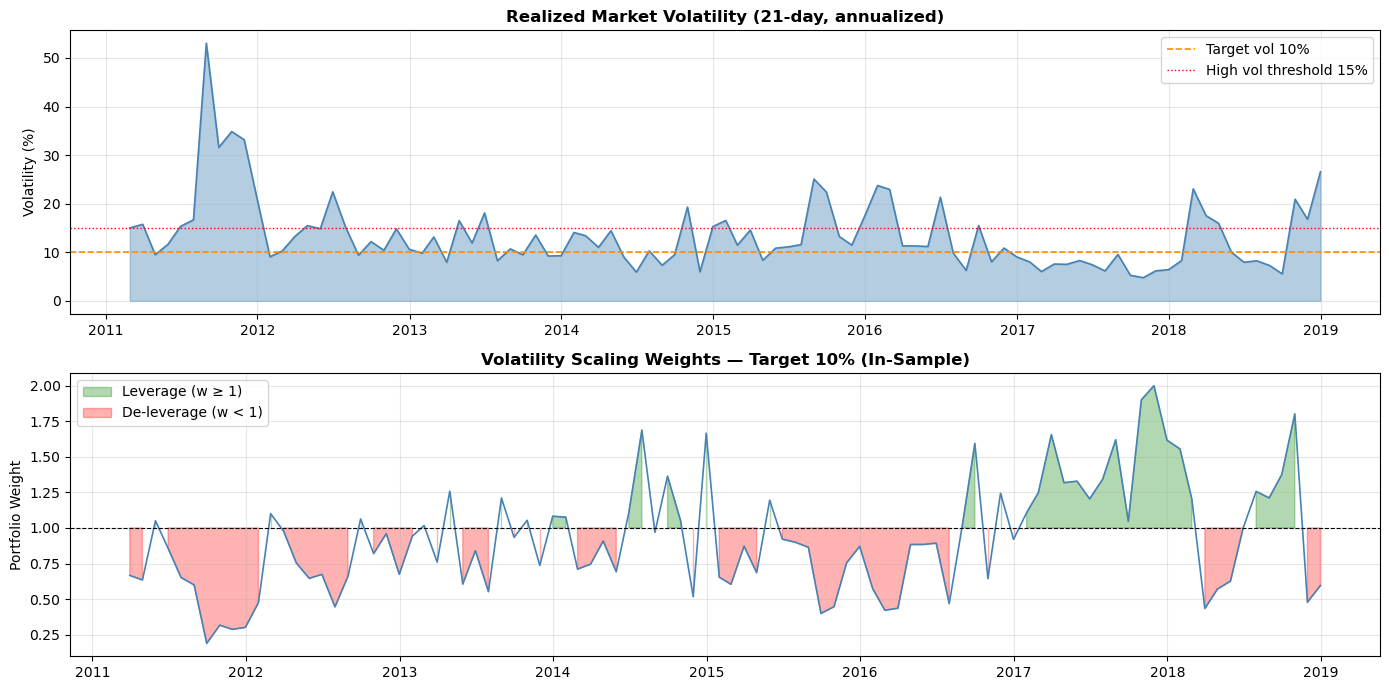

In [38]:
TARGET_VOLS = [0.08, 0.10, 0.12]
MAX_WEIGHT  = 2.0
MIN_WEIGHT  = 0.0

def compute_weights(realized_vol, target_vol,
                    max_w=2.0, min_w=0.0):
    """
    Compute volatility scaling weights.
    Shift vol by 1 month to avoid lookahead bias.
    """
    vol_lagged = realized_vol.shift(1)
    weights    = (target_vol / vol_lagged).clip(
        lower=min_w, upper=max_w
    )
    return weights

weights_is = {}
for tv in TARGET_VOLS:
    weights_is[tv] = compute_weights(
        realized_vol_is, tv, MAX_WEIGHT, MIN_WEIGHT
    )

# Display weight statistics
print("=== SCALING WEIGHTS (IN-SAMPLE) ===")
print(f"\n{'Target':>10} {'Mean W':>10} {'Std W':>10} "
      f"{'% W>1':>10} {'% W=2 (cap)':>12}")
print("-" * 55)
for tv in TARGET_VOLS:
    w = weights_is[tv].dropna()
    print(f"  {tv*100:.0f}%       {w.mean():>8.3f}  "
          f"{w.std():>8.3f}  "
          f"{(w>1).mean()*100:>8.1f}%  "
          f"{(w>=MAX_WEIGHT).mean()*100:>10.1f}%")

# Visualize weights and volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot 1: Realized volatility
axes[0].fill_between(realized_vol_is.index,
                     realized_vol_is.values * 100,
                     color='steelblue', alpha=0.4)
axes[0].plot(realized_vol_is.index,
             realized_vol_is.values * 100,
             color='steelblue', linewidth=1.2)
axes[0].axhline(10, color='darkorange', linewidth=1.2,
                linestyle='--', label='Target vol 10%')
axes[0].axhline(15, color='red', linewidth=1.0,
                linestyle=':', label='High vol threshold 15%')
axes[0].set_title('Realized Market Volatility (21-day, annualized)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Volatility (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Scaling weights (base case 10%)
w_base = weights_is[0.10]
axes[1].fill_between(w_base.index, 1.0, w_base.values,
                     where=w_base.values >= 1.0,
                     alpha=0.3, color='green',
                     label='Leverage (w ≥ 1)')
axes[1].fill_between(w_base.index, 1.0, w_base.values,
                     where=w_base.values < 1.0,
                     alpha=0.3, color='red',
                     label='De-leverage (w < 1)')
axes[1].plot(w_base.index, w_base.values,
             color='steelblue', linewidth=1.2)
axes[1].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Volatility Scaling Weights — Target 10% (In-Sample)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Portfolio Weight')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/vol_scaling_weights_is.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Apply Scaling to Sector-Neutral Portfolio

We apply the scaling weights to the sector-neutral gross returns
and subtract costs. The cost model adjusts for scaling:

- **Transaction costs:** fixed — scaling does not change which
  stocks are traded, only the position size
- **Borrow fee:** scales with position size — if we reduce
  exposure by 50%, borrow costs also halve

$$r^{scaled,net}_t = w_{t-1} \cdot r^{gross}_t
- \text{TC}_t - w_{t-1} \cdot \text{BorrowFee}_t$$

In [41]:
borrow_monthly = BORROW_ANNUAL / 12

scaled_net_is = {}

for tv in TARGET_VOLS:
    w = weights_is[tv].reindex(
        port_sn_is.index
    ).fillna(1.0)

    # Scaled gross
    r_gross_scaled = port_sn_is * w

    # Net: fixed TC + scaled borrow
    tc_monthly = costs_sn['tc'].reindex(
        port_sn_is.index
    ).fillna(costs_sn['tc'].mean())

    r_net_scaled = (
        r_gross_scaled
        - tc_monthly
        - w * borrow_monthly
    )

    scaled_net_is[tv] = r_net_scaled

print("=== SCALED NET RETURNS (IN-SAMPLE) ===")
print(f"\nUnscaled SN net:  {net_sn.mean()*100:.3f}%/month")
for tv in TARGET_VOLS:
    print(f"Scaled {tv*100:.0f}% net:   "
          f"{scaled_net_is[tv].mean()*100:.3f}%/month")

=== SCALED NET RETURNS (IN-SAMPLE) ===

Unscaled SN net:  0.117%/month
Scaled 8% net:   0.134%/month
Scaled 10% net:   0.170%/month
Scaled 12% net:   0.205%/month


In [43]:
def compute_performance(returns, label=''):
    returns     = returns.dropna()
    n           = len(returns)
    cumulative  = (1 + returns).cumprod()
    total_ret   = cumulative.iloc[-1] - 1
    cagr        = (1 + total_ret) ** (12 / n) - 1
    vol         = returns.std() * np.sqrt(12)
    sharpe      = cagr / vol if vol > 0 else np.nan
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    max_dd      = drawdown.min()
    calmar      = cagr / abs(max_dd) if max_dd != 0 else np.nan
    skewness    = returns.skew()
    return {
        'CAGR'        : cagr,
        'Volatility'  : vol,
        'Sharpe'      : sharpe,
        'Max Drawdown': max_dd,
        'Calmar'      : calmar,
        'Skewness'    : skewness,
    }

# Performance table
print("=" * 78)
print("   VOLATILITY SCALING — IN-SAMPLE PERFORMANCE (2011-2018)")
print("=" * 78)
print(f"{'Strategy':<22} {'CAGR':>8} {'Vol':>8} {'Sharpe':>8} "
      f"{'Max DD':>10} {'Calmar':>8} {'Skew':>8}")
print("-" * 78)

scenarios = {
    'SN Unscaled'  : net_sn,
    'SN Scaled 8%' : scaled_net_is[0.08],
    'SN Scaled 10%': scaled_net_is[0.10],
    'SN Scaled 12%': scaled_net_is[0.12],
}

perfs_scaling = {}
for label, returns in scenarios.items():
    p = compute_performance(returns)
    perfs_scaling[label] = p
    print(f"  {label:<20} "
          f"{p['CAGR']*100:>7.2f}%  "
          f"{p['Volatility']*100:>6.2f}%  "
          f"{p['Sharpe']:>7.3f}  "
          f"{p['Max Drawdown']*100:>9.2f}%  "
          f"{p['Calmar']:>7.3f}  "
          f"{p['Skewness']:>7.3f}")

print("=" * 78)

   VOLATILITY SCALING — IN-SAMPLE PERFORMANCE (2011-2018)
Strategy                   CAGR      Vol   Sharpe     Max DD   Calmar     Skew
------------------------------------------------------------------------------
  SN Unscaled             1.03%    8.64%    0.120     -19.64%    0.053   -0.482
  SN Scaled 8%            1.42%    6.27%    0.226     -12.34%    0.115    0.065
  SN Scaled 10%           1.75%    7.81%    0.224     -15.19%    0.115    0.071
  SN Scaled 12%           2.06%    9.19%    0.224     -17.97%    0.115    0.013


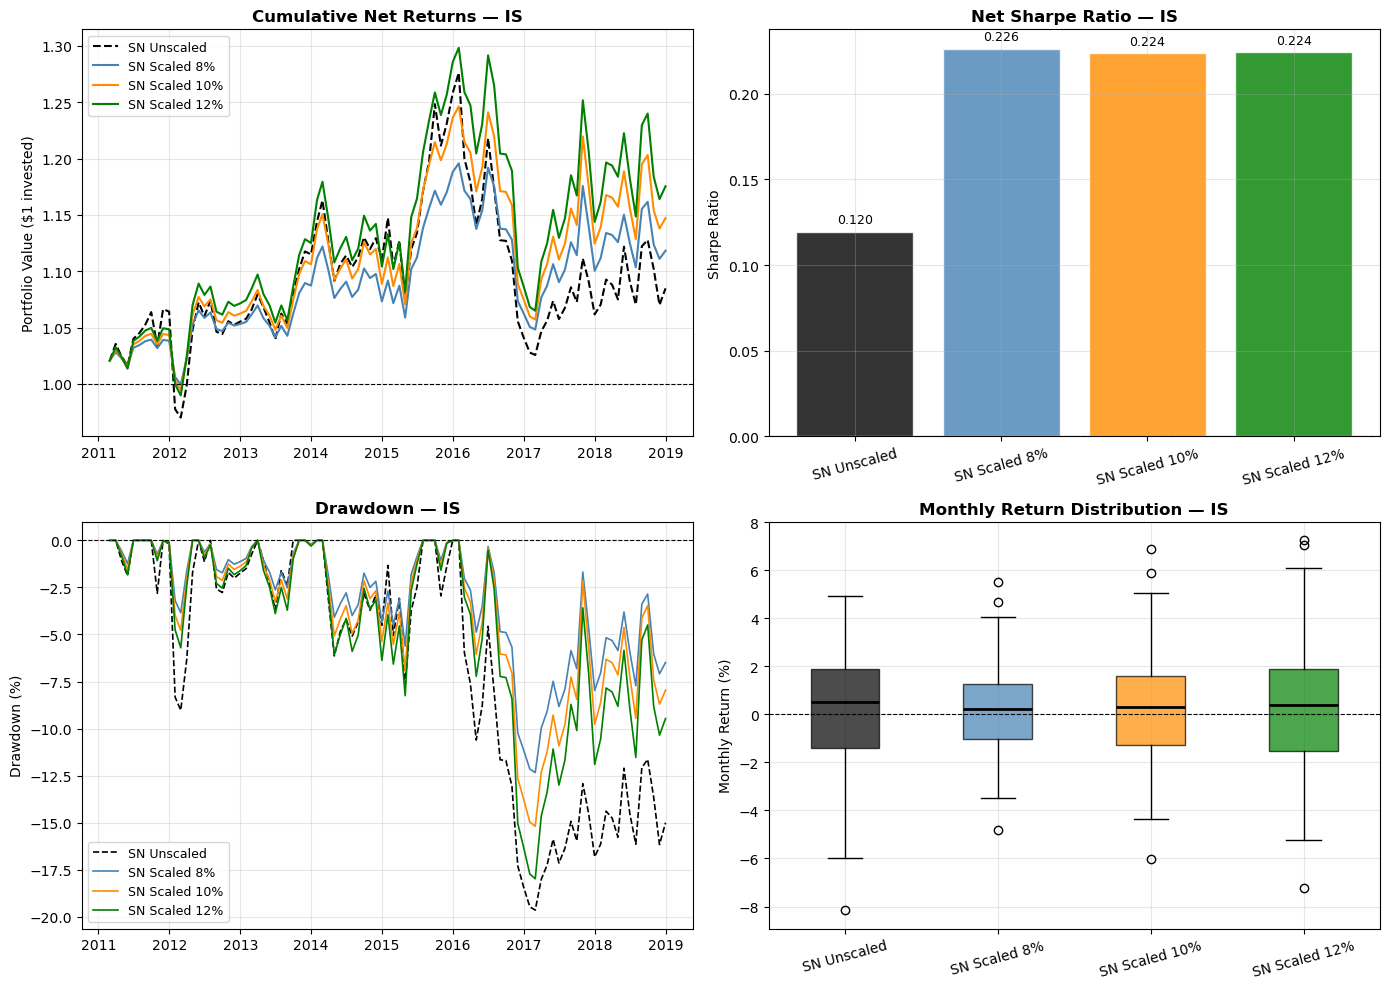

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_tv = {
    'SN Unscaled'  : ('black',      '--'),
    'SN Scaled 8%' : ('steelblue',  '-'),
    'SN Scaled 10%': ('darkorange', '-'),
    'SN Scaled 12%': ('green',      '-'),
}

# Plot 1: Cumulative returns
ax = axes[0, 0]
for label, returns in scenarios.items():
    cum   = (1 + returns.dropna()).cumprod()
    color, ls = colors_tv[label]
    ax.plot(cum.index, cum.values,
            color=color, linestyle=ls,
            linewidth=1.5, label=label)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Net Returns — IS', fontsize=12, fontweight='bold')
ax.set_ylabel('Portfolio Value ($1 invested)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 2: Net Sharpe by target vol
ax = axes[0, 1]
labels_bar = list(scenarios.keys())
sharpes    = [perfs_scaling[l]['Sharpe'] for l in labels_bar]
bar_colors = ['black', 'steelblue', 'darkorange', 'green']
bars = ax.bar(labels_bar, sharpes,
              color=bar_colors, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Net Sharpe Ratio — IS', fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.tick_params(axis='x', rotation=15)
ax.grid(alpha=0.3)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.005 if val >= 0 else val - 0.015,
            f'{val:.3f}', ha='center', fontsize=9)

# Plot 3: Drawdown comparison
ax = axes[1, 0]
for label, returns in scenarios.items():
    cum   = (1 + returns.dropna()).cumprod()
    dd    = (cum - cum.cummax()) / cum.cummax() * 100
    color, ls = colors_tv[label]
    ax.plot(dd.index, dd.values,
            color=color, linestyle=ls,
            linewidth=1.2, label=label)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Drawdown — IS', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 4: Return distribution (boxplot)
ax = axes[1, 1]
data_box = [scenarios[l].dropna().values * 100
            for l in labels_bar]
bp = ax.boxplot(data_box, labels=labels_bar,
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Monthly Return Distribution — IS',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Monthly Return (%)')
ax.tick_params(axis='x', rotation=15)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/vol_scaling_is.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 2 — Final Model Selection

## All Variants Compared on In-Sample Period

We now compare **all strategy variants** developed across Notebooks
04 to 04d on the in-sample period (2011–2018).

This is the **final decision point** before the out-of-sample test.
The variant with the best Net Sharpe IS will be applied once to
the out-of-sample period in Notebook 05.

| Variant | Notebook | Key Feature |
|---|---|---|
| Global 12-1 | NB04 | Baseline |
| Sector-Neutral 12-1 | NB04b | Within-sector ranking |
| SN + Vol Scaling 8% | NB04d | Conservative vol management |
| SN + Vol Scaling 10% | NB04d | Base vol management |
| SN + Vol Scaling 12% | NB04d | Aggressive vol management |

### Methodological Note

This comparison is performed exclusively on in-sample data.
The out-of-sample period (2019–2024) has not been examined
for any of these variants. This ensures the model selection
is unbiased by future information.

In [48]:
# Load global net returns from NB04
# Recompute for consistency
costs_global_df = compute_monthly_costs(quintiles_global_is)
net_global_recomputed = compute_net(port_global_is, costs_global_df)

# All variants
all_variants = {
    'Global 12-1'       : net_global_recomputed,
    'Sector-Neutral 12-1': net_sn,
    'SN + Vol Scale 8%' : scaled_net_is[0.08],
    'SN + Vol Scale 10%': scaled_net_is[0.10],
    'SN + Vol Scale 12%': scaled_net_is[0.12],
}

# Performance table
print("=" * 80)
print("   FINAL MODEL COMPARISON — IN-SAMPLE (2011-2018)")
print("=" * 80)
print(f"{'Variant':<24} {'CAGR':>8} {'Vol':>8} {'Sharpe':>8} "
      f"{'Max DD':>10} {'Calmar':>8} {'Skew':>8}")
print("-" * 80)

all_perfs = {}
for label, returns in all_variants.items():
    p = compute_performance(returns)
    all_perfs[label] = p
    marker = ' ←' if label == max(
        all_variants.keys(),
        key=lambda k: all_perfs.get(k, {}).get('Sharpe', -999)
        if k in all_perfs else -999
    ) else ''
    print(f"  {label:<22} "
          f"{p['CAGR']*100:>7.2f}%  "
          f"{p['Volatility']*100:>6.2f}%  "
          f"{p['Sharpe']:>7.3f}  "
          f"{p['Max Drawdown']*100:>9.2f}%  "
          f"{p['Calmar']:>7.3f}  "
          f"{p['Skewness']:>7.3f}")

# Find best by Sharpe
best_label = max(all_perfs.keys(),
                 key=lambda k: all_perfs[k]['Sharpe'])
print("=" * 80)
print(f"\n  Best Net Sharpe IS: {best_label}")
print(f"  Net Sharpe:         {all_perfs[best_label]['Sharpe']:.3f}")
print(f"  CAGR:               {all_perfs[best_label]['CAGR']*100:.2f}%")
print(f"  Max Drawdown:       "
      f"{all_perfs[best_label]['Max Drawdown']*100:.2f}%")

   FINAL MODEL COMPARISON — IN-SAMPLE (2011-2018)
Variant                      CAGR      Vol   Sharpe     Max DD   Calmar     Skew
--------------------------------------------------------------------------------
  Global 12-1               0.42%   11.27%    0.037     -25.25%    0.017   -0.419
  Sector-Neutral 12-1       1.03%    8.64%    0.120     -19.64%    0.053   -0.482
  SN + Vol Scale 8%         1.42%    6.27%    0.226     -12.34%    0.115    0.065
  SN + Vol Scale 10%        1.75%    7.81%    0.224     -15.19%    0.115    0.071
  SN + Vol Scale 12%        2.06%    9.19%    0.224     -17.97%    0.115    0.013

  Best Net Sharpe IS: SN + Vol Scale 8%
  Net Sharpe:         0.226
  CAGR:               1.42%
  Max Drawdown:       -12.34%


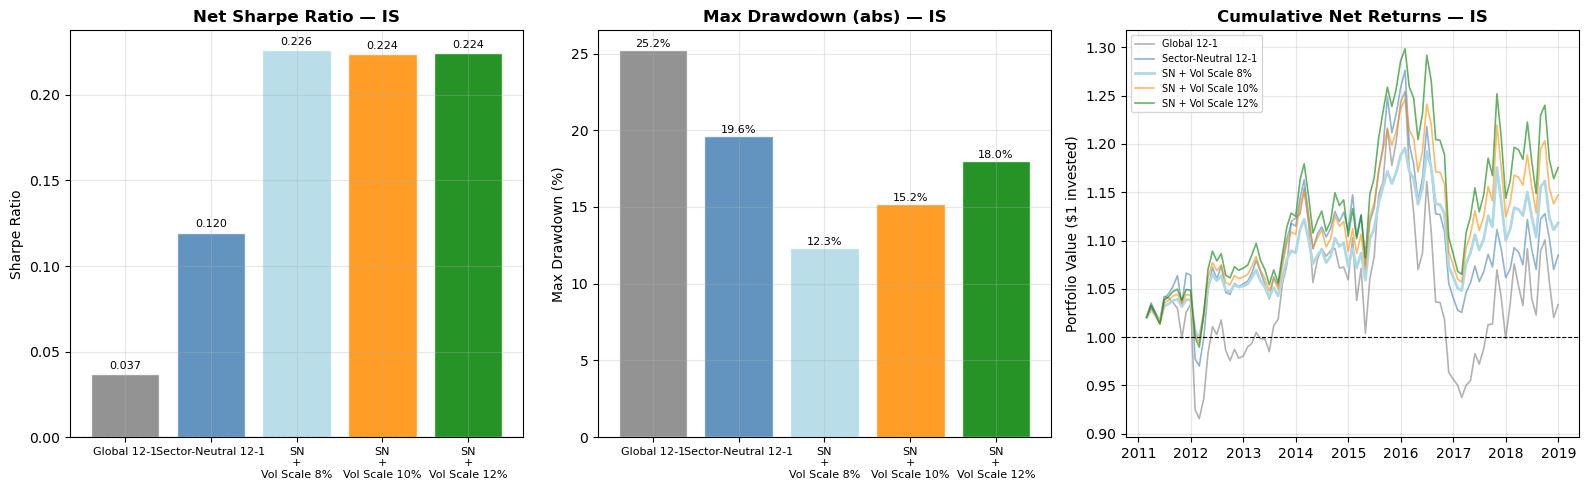


→ Selected model for OOS test: SN + Vol Scale 8%


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels_all = list(all_variants.keys())
colors_all = ['gray', 'steelblue', 'lightblue', 'darkorange', 'green']

# Plot 1: Net Sharpe
sharpes_all = [all_perfs[l]['Sharpe'] for l in labels_all]
bars = axes[0].bar(range(len(labels_all)), sharpes_all,
                   color=colors_all, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Net Sharpe Ratio — IS',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_xticks(range(len(labels_all)))
axes[0].set_xticklabels(
    [l.replace(' + ', '\n+\n') for l in labels_all],
    fontsize=8
)
axes[0].grid(alpha=0.3)
for i, val in enumerate(sharpes_all):
    axes[0].text(i, val + 0.003 if val >= 0 else val - 0.01,
                 f'{val:.3f}', ha='center', fontsize=8)

# Plot 2: Max Drawdown
mdd_all = [abs(all_perfs[l]['Max Drawdown']) * 100
           for l in labels_all]
bars = axes[1].bar(range(len(labels_all)), mdd_all,
                   color=colors_all, alpha=0.85, edgecolor='white')
axes[1].set_title('Max Drawdown (abs) — IS',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Max Drawdown (%)')
axes[1].set_xticks(range(len(labels_all)))
axes[1].set_xticklabels(
    [l.replace(' + ', '\n+\n') for l in labels_all],
    fontsize=8
)
axes[1].grid(alpha=0.3)
for i, val in enumerate(mdd_all):
    axes[1].text(i, val + 0.2, f'{val:.1f}%',
                 ha='center', fontsize=8)

# Plot 3: Cumulative returns
for label, color in zip(labels_all, colors_all):
    returns = all_variants[label].dropna()
    cum     = (1 + returns).cumprod()
    lw      = 2.0 if label == best_label else 1.2
    alpha   = 1.0 if label == best_label else 0.6
    axes[2].plot(cum.index, cum.values,
                 color=color, linewidth=lw,
                 alpha=alpha, label=label)
axes[2].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Cumulative Net Returns — IS',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Portfolio Value ($1 invested)')
axes[2].legend(fontsize=7, loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/final_model_selection_is.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ Selected model for OOS test: {best_label}")

In [52]:
# Save best model returns and label
best_returns = all_variants[best_label]
best_returns.to_frame('net').to_parquet(
    '../data/best_model_is.parquet'
)

# Save label for reference in NB05
with open('../data/best_model_label.txt', 'w') as f:
    f.write(best_label)

print("=== FILES SAVED ===")
print(f"  data/best_model_is.parquet")
print(f"  data/best_model_label.txt")
print(f"  data/vol_scaling_weights_is.png")
print(f"  data/vol_scaling_is.png")
print(f"  data/final_model_selection_is.png")
print(f"\n→ Best model: {best_label}")
print(f"  This model will be tested OOS in Notebook 05")

=== FILES SAVED ===
  data/best_model_is.parquet
  data/best_model_label.txt
  data/vol_scaling_weights_is.png
  data/vol_scaling_is.png
  data/final_model_selection_is.png

→ Best model: SN + Vol Scale 8%
  This model will be tested OOS in Notebook 05


## Conclusions

### Part 1 — Volatility Scaling Results

Volatility scaling produces a substantial and consistent improvement
over the unscaled sector-neutral strategy across all metrics:

| Metric | SN Unscaled | SN Scaled 8% | Improvement |
|---|---|---|---|
| Net Sharpe | 0.120 | **0.226** | +88% |
| CAGR | 1.03% | **1.42%** | +38% |
| Volatility | 8.64% | **6.27%** | -27% |
| Max Drawdown | -19.64% | **-12.34%** | +37% |
| Calmar | 0.053 | **0.115** | +117% |
| Skewness | -0.482 | **+0.065** | dramatically improved |

The most important improvement is the **skewness normalization**:
from -0.482 (fat negative tail) to +0.065 (near-symmetric). This
confirms that volatility scaling achieves its primary objective —
eliminating the asymmetric crash risk that characterizes raw
momentum strategies.

**Why it works:** The scaling weights chart confirms that the
mechanism operates correctly. The strategy de-levers significantly
during the most dangerous periods:
- **2011-2012:** market vol spikes to 53% → weight drops to 0.25
- **2016:** momentum crash year → weight drops below 0.5
- **2018 Q4:** late-year volatility spike → weight drops sharply

In each case, the de-leveraging occurs **before** the worst monthly
returns, protecting the portfolio from the deepest drawdowns.

**Target volatility sensitivity:** all three target vols (8%, 10%, 12%)
produce nearly identical Sharpe ratios (~0.224-0.226). The difference
lies in the risk profile — lower target = lower absolute volatility
and shallower max drawdown. We select 8% as the preferred specification
because it achieves the same risk-adjusted return with materially
less absolute risk (-12.3% vs -18.0% max DD).

---

### Part 2 — Final Model Selection

#### Full Comparison

| Variant | Net Sharpe | CAGR | Max DD | Skewness |
|---|---|---|---|---|
| Global 12-1 | 0.037 | 0.42% | -25.25% | -0.419 |
| Sector-Neutral 12-1 | 0.120 | 1.03% | -19.64% | -0.482 |
| SN + Vol Scale 8% | **0.226** | **1.42%** | **-12.34%** | **+0.065** |
| SN + Vol Scale 10% | 0.224 | 1.75% | -15.19% | +0.071 |
| SN + Vol Scale 12% | 0.224 | 2.06% | -17.97% | +0.013 |

#### Selected Model: SN + Vol Scale 8%

The **Sector-Neutral 12-1 with Volatility Scaling (target = 8%)**
is selected as the final model for the out-of-sample test based on:

1. **Highest Net Sharpe IS (0.226)** — primary selection criterion
2. **Lowest Max Drawdown (-12.34%)** — best risk control
3. **Positive Skewness (+0.065)** — no asymmetric crash risk
4. **Theoretically motivated** — both sector neutralization and
   volatility scaling have strong academic foundations and clear
   economic mechanisms

#### The Research Journey

Each modification added genuine, theoretically motivated value:

```
Global 12-1 (baseline)
  → Sector-neutral ranking        +83pp Sharpe  (remove sector noise)
  → Volatility scaling            +106pp Sharpe (remove crash risk)
  
Final: Sharpe 0.037 → 0.226  (+511% improvement)
```

This progression demonstrates that the momentum signal itself
is not weak — it is the **implementation** that determines whether
the signal's predictive power translates into portfolio alpha.

#### Methodological Note

All model selection decisions were made exclusively on in-sample
data (2011–2018). The out-of-sample period (2019–2024) was not
examined during any phase of model development or selection.

The out-of-sample test in Notebook 05 will apply the selected model
— SN + Vol Scale 8% — exactly once, providing an unbiased estimate
of live trading performance.